## Preliminary study of SNIa population with skysurvey

We analyse the lightcurves here and also compare theoretical detections and $5\sigma$ detections. We define theoretical detections where at least one point on the smooth theoretical lightcurve (it's better to plot in terms of observed magnitude i.e. in_mag = True, since skysurvey uses it's own limiting flux from maglimit, thus it will hardly follow our theoretical minimum flux for detection in each band).

In [1]:
# imported required packages
import skysurvey
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from lightcurve import generate_snia_lightcurve, plot_lightcurve, limit_mag_dict, get_valid_bands
from lightcurve import generate_snia_dict, generate_ordered_parameter_list, determine_visibility

import sncosmo

lsst_colors = ["tab:purple", "tab:green", "tab:orange", "tab:red", "tab:brown", "0.5"]
bands = ["lsstu", "lsstg", "lsstr", "lssti", "lsstz", "lssty"]
snia_lightcurve_params = ["z", "x1", "c", "t0", "magabs", "ra", "dec"]

from lsst_functions import set_selection_criteria
selection_criteria = set_selection_criteria(total_points=5,n_filters=2,min_points_per_filter=2)

/home/denzelgoh/micromamba/envs/TransietnLightcurves/lib/python3.14/site-packages/ligo/skymap/bayestar/__init__.py:34: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [2]:
# load the 10 year population
opsim_path = "baseline_v5.3.5_10yrs.db" # provide fullpath

lsst = skysurvey.LSST.from_opsim(opsim_path, sql_where="night < 365")
# if you want to choose only one band, use: band IN ('g') AND night < 365
# IMPORTANT: remove the _## from the band names in the lsst observation
lsst.data["band"] = (lsst.data["band"].str.replace(r"_\d+$", "", regex=True))
lsst.data["band"].unique()

<ArrowStringArray>
['lsstu', 'lsstr', 'lsstg', 'lssti', 'lsstz', 'lssty']
Length: 6, dtype: str

Note about graph colours: `skysurvey` uses `from skysurvey.config import get_band_color` to use a specific color for each band when ploting graphs. You can use this, but you can use our lsst_colors too (also inside `lightcurve.limit_mag_dict`)

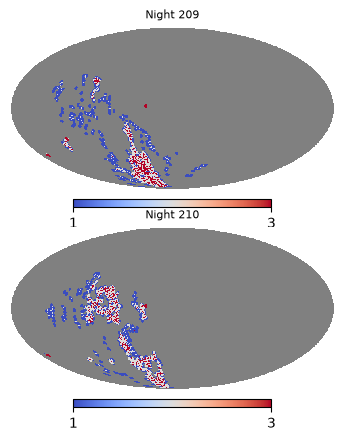

In [3]:
# visualise individual night observations for your interest
from lsst_functions import visualize_nights
visualize_nights(opsim_path, start_night=209, stop_night=211)

In [4]:
lsst.data.columns

Index(['skynoise', 'mjd', 'band', 'gain', 'zp', 'ra', 'dec', 'observationId',
       'fieldid_survey', 'fieldid'],
      dtype='str')

In [5]:
lsst.data.head()

,skynoise,mjd,band,gain,zp,ra,dec,observationId,fieldid_survey,fieldid
0,88.769341,61208.203125,lsstu,1,30,262.411621,-78.815239,0,0,474007
1,88.769341,61208.203125,lsstu,1,30,262.411621,-78.815239,0,0,474008
2,88.769341,61208.203125,lsstu,1,30,262.411621,-78.815239,0,0,474009
3,88.769341,61208.203125,lsstu,1,30,262.411621,-78.815239,0,0,474010
4,88.769341,61208.203125,lsstu,1,30,262.411621,-78.815239,0,0,474011


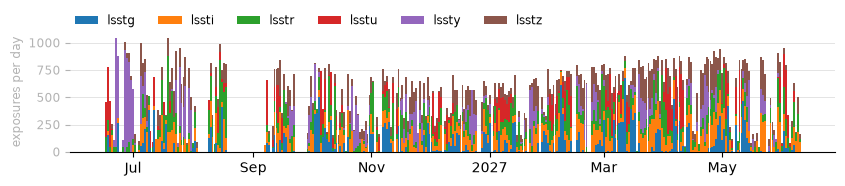

In [6]:
fig = lsst.show_nexposures(exposure_key="observationId")

In [7]:
lsst.data[lsst.data['fieldid'] == 474009].head(10)

,skynoise,mjd,band,gain,zp,ra,dec,observationId,fieldid_survey,fieldid
2,88.769341,61208.203125,lsstu,1,30,262.411621,-78.815239,0,0,474009
729,71.667374,61208.203125,lsstu,1,30,265.602020,-77.358208,6,6,474009
1331,81.148010,61208.207031,lsstu,1,30,264.967010,-75.771973,11,11,474009
71531,94.095505,61209.132812,lsstu,1,30,260.472870,-76.249313,646,646,474009
479061,356.150421,61218.113281,lssty,1,30,263.992859,-75.561653,4315,4315,474009
712431,294.086578,61220.253906,lssty,1,30,268.981934,-77.110123,6417,6417,474009
716982,171.078552,61220.273438,lsstz,1,30,263.344421,-78.683006,6458,6458,474009
943122,200.201218,61226.015625,lsstz,1,30,258.859924,-78.667793,8503,8503,474009
1064015,57.544468,61227.054688,lsstr,1,30,265.298004,-78.184036,9595,9595,474009
1068970,54.989235,61227.074219,lsstr,1,30,265.698242,-77.884766,9639,9639,474009


In [8]:
from astropy.time import Time
tmin, tmax = lsst.date_range
print(f"Start: {Time(tmin, format='mjd').iso}")
print(f"End:   {Time(tmax, format='mjd').iso}")
print(f"Duration: {(tmax - tmin)/365.25:.1f} years")
lsst.date_range

Start: 2026-06-17 04:52:30.000
End:   2027-06-10 01:46:52.500
Duration: 1.0 years


(np.float32(61208.203), np.float32(61566.074))

### Generating a test population

In [9]:
snia_dict = generate_snia_dict(redshift = 0.2, ra = None, dec = None, x1 = 0.0, t0 = None, magabs = -18.523, c = 0.0)
snia_param_list = generate_ordered_parameter_list(input_dict = True, params = snia_dict)
snia_models, data_models = generate_snia_lightcurve(*snia_param_list, bands = bands, in_mag = False, N_tot = 100, tstart = tmin, tstop = tmax, zp=30, plot_curve = False, return_values = True, return_models = True, verbose = False)

CUSTOM MODEL IS {'radec': {'as': ['ra', 'dec'], 'func': <function random_radec at 0x73f171734bf0>, 'kwargs': {'dec_range': [-90, 90]}}, 'redshift': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 100, 'value': 0.2}, 'as': 'z'}, 'x1': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 100, 'value': 0.0}, 'as': 'x1'}, 'c': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 100, 'value': 0.0}, 'as': 'c'}, 'magabs': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 100, 'value': -18.523}, 'as': 'magabs'}}


In [10]:
snia_models.data.loc[0]

z                    0.2
x1                   0.0
c                    0.0
t0          61479.457031
magabs        -18.523001
ra            150.872665
dec            21.400225
magobs         21.503532
template           salt2
Name: 0, dtype: object

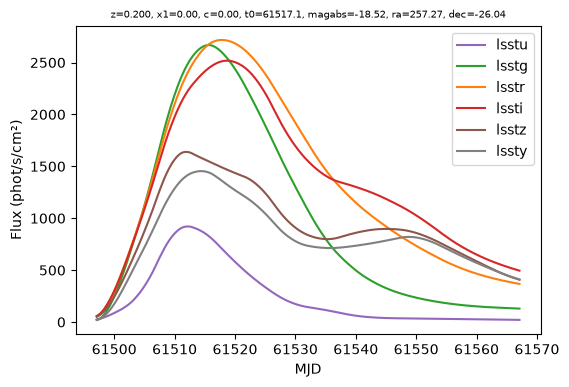

In [16]:
# choose a model and plo
from lightcurve import plot_lightcurve
model = data_models[8]
fig = plot_lightcurve(model, times=model['times'], in_mag = False)


In [12]:
# now simulate what would be observed by LSST
dset = skysurvey.DataSet.from_targets_and_survey(snia_models, lsst, progress_bar=True, discard_bands=True)

100%|██████████| 61/61 [00:03<00:00, 17.83it/s]


In [18]:
# see data for a chosen index
dset.data.loc[0].head()

,mjd,band,skynoise,gain,zp,fieldid,flux,fluxerr
index_obs,,,,,,,,
9848778,61421.230469,lsstr,41.895329,1,30,151664,-51.448801,41.895328
10308366,61431.210938,lsstz,188.742966,1,30,151664,27.266280,188.742963
10308458,61431.210938,lsstz,203.156250,1,30,151664,-433.549921,203.156248
10312177,61431.230469,lssti,150.552826,1,30,151664,147.254720,150.552829
10992591,61443.250000,lsstg,35.199539,1,30,151664,-19.266408,35.199539


In [19]:
# show per-band detections
dset.get_ndetection(per_band = True).loc[0]

band
lsstg    4
lssti    3
lsstr    4
lsstz    2
dtype: int64

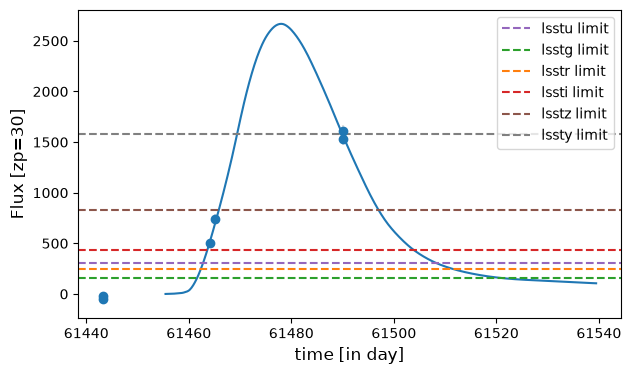

In [24]:
# DataSet instances also has a built-in function which plots the theoretical lc and the observations
# the kwarg show_truth = True plots this theoretical lc

dset.show_target_lightcurve(index = 0, phase_window=[-60,200], zp = 30, bands = ['lsstg'], format_time = False)

ax = plt.gca()
for band in bands:
    ax.axhline(
        limit_mag_dict[band]["flux"],
        color=limit_mag_dict[band]["color"],
        linestyle="--",
        label=f"{band} limit",
    )
ax.legend()

## Predicting the maximum z limit where we can detect SNIa + in each band

Loop through different redshifts with a for loop and generate populations of SNIa at that fixed redshift but with all other parameters randomised.

We use a reasonable SNIa absolute magnitude `magabs =  -19.323`

In [25]:
N_tot = 1000

from lsst_functions import set_selection_criteria
selection_criteria = set_selection_criteria(total_points=5,n_filters=2,min_points_per_filter=2)

redshift_list = [0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75]
from lsst_functions import detectability_sources


snia_dict = generate_snia_dict(redshift=None,ra=None,dec=None,x1=None,t0=None,magabs=-19.323,c=None)
snia_param_list = generate_ordered_parameter_list(input_dict=True,params=snia_dict)

final_summary = detectability_sources(snia_param_list = snia_param_list, opsim = lsst, N_tot = N_tot, redshift_list = redshift_list)

Start: 2026-06-17 04:52:30.000
End:   2027-06-10 01:46:52.500
Duration: 1.0 years
[0.15, None, None, None, -19.323, None, None]
CUSTOM MODEL IS {'radec': {'as': ['ra', 'dec'], 'func': <function random_radec at 0x73f171734bf0>, 'kwargs': {'dec_range': [-90, 90]}}, 'redshift': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': 0.15}, 'as': 'z'}, 'magabs': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': -19.323}, 'as': 'magabs'}}


100%|██████████| 691/691 [00:17<00:00, 40.64it/s]


[0.2, None, None, None, -19.323, None, None]
CUSTOM MODEL IS {'radec': {'as': ['ra', 'dec'], 'func': <function random_radec at 0x73f171734bf0>, 'kwargs': {'dec_range': [-90, 90]}}, 'redshift': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': 0.2}, 'as': 'z'}, 'magabs': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': -19.323}, 'as': 'magabs'}}


100%|██████████| 691/691 [00:13<00:00, 49.75it/s]


[0.25, None, None, None, -19.323, None, None]
CUSTOM MODEL IS {'radec': {'as': ['ra', 'dec'], 'func': <function random_radec at 0x73f171734bf0>, 'kwargs': {'dec_range': [-90, 90]}}, 'redshift': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': 0.25}, 'as': 'z'}, 'magabs': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': -19.323}, 'as': 'magabs'}}


...

100%|██████████| 688/688 [00:05<00:00, 129.88it/s]


[0.7, None, None, None, -19.323, None, None]
CUSTOM MODEL IS {'radec': {'as': ['ra', 'dec'], 'func': <function random_radec at 0x73f171734bf0>, 'kwargs': {'dec_range': [-90, 90]}}, 'redshift': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': 0.7}, 'as': 'z'}, 'magabs': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': -19.323}, 'as': 'magabs'}}


100%|██████████| 666/666 [00:08<00:00, 83.24it/s] 


[0.75, None, None, None, -19.323, None, None]
CUSTOM MODEL IS {'radec': {'as': ['ra', 'dec'], 'func': <function random_radec at 0x73f171734bf0>, 'kwargs': {'dec_range': [-90, 90]}}, 'redshift': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': 0.75}, 'as': 'z'}, 'magabs': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': -19.323}, 'as': 'magabs'}}


100%|██████████| 679/679 [00:08<00:00, 82.64it/s] 


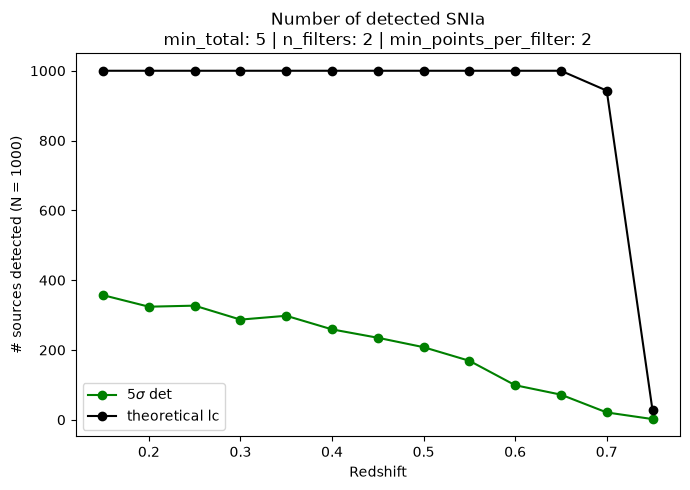

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(final_summary["z"],final_summary["n_detected"],marker="o", color = "g", label = '5$\\sigma$ det')
ax.plot(final_summary["z"],final_summary["n_detected_theoretical"],marker="o", color = "k", label = 'theoretical lc')

ax.set_xlabel("Redshift")
ax.set_ylabel(f"# sources detected (N = {N_tot})")
ax.set_title(
    f"Number of detected SNIa\n"
    f"min_total: {selection_criteria['total_points']} | "
    f"n_filters: {selection_criteria['n_filters']} | "
    f"min_points_per_filter: {selection_criteria['min_points_per_filter']}"
)
plt.tight_layout
plt.legend()
plt.show()

In [32]:
import importlib
import lsst_functions
# uncomment and run the following and run them if you wantu
importlib.reload(lsst_functions)
from lsst_functions import five_sigma_detection_by_band, five_sigma_detection_multiband, five_sigma_detection_by_band_multiband, compare_detection_conditions

Here, for each redshift, we keep
`ra=14.9, dec=-22.4, x1=0.0, t0=61250.0, magabs=-18.523,c=0.0`
Note that `magabs = -18.523` is on the dimmer end. There is no particular reason why I used for -18.523 and -19.323 in this notebook.

Even though we simulate N_tot of duplicated lightcurves, the actual observations will differ a bit due random observation effects; that is why we want to ensure we capture this uncertainty by simulating 500 sources rather than just 1.

In [64]:
N_tot = 1000
all_summaries = []
lsst_bands = bands
for redshift in [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]:

    snia_dict = generate_snia_dict(redshift=redshift, ra=14.9, dec=-22.4, x1=0.0, t0=61250.0, magabs=-18.523,c=0.0)
    snia_param_list = generate_ordered_parameter_list(input_dict=True,params=snia_dict)
    snia_models, data_models = generate_snia_lightcurve(*snia_param_list,bands=bands,in_mag=False,N_tot=N_tot,zp=30,plot_curve=False,return_values=True,return_models=True,verbose=False)
    dset = skysurvey.DataSet.from_targets_and_survey(snia_models, lsst,progress_bar=True,discard_bands=True)

    # Get detection results for every target
    target_results = []

    for index in snia_models.data.index:

        result = compare_detection_conditions(dataset=dset,targets=snia_models,data_models=data_models,index=index)

        target_results.append(result)

    target_results = pd.concat(target_results,ignore_index=True)

    # Sum detections over all targets
    summary = (target_results.groupby("condition")[lsst_bands].sum().reset_index())

    # Convert to average number of detections per target
    summary[lsst_bands]

    # Add redshift
    summary["z"] = redshift

    # Add the other fixed parameters
    for col in ["x1", "c", "t0", "magabs", "ra", "dec"]:
        summary[col] = snia_models.data[col].iloc[0]

    # Keep useful column order
    summary = summary[["condition", "z","x1","c","t0","magabs","ra","dec"] + lsst_bands]
    all_summaries.append(summary)

# Combine all redshifts
final_summary = pd.concat(all_summaries,ignore_index=True)

print(final_summary)

CUSTOM MODEL IS {'redshift': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': 0.01}, 'as': 'z'}, 'x1': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': 0.0}, 'as': 'x1'}, 'c': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': 0.0}, 'as': 'c'}, 't0': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': 61250.0}, 'as': 't0'}, 'magabs': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': -18.523}, 'as': 'magabs'}, 'radec': {'func': <function fixed_radec at 0x73f16e1ceb90>, 'kwargs': {'size': 1000, 'ra': 14.9, 'dec': -22.4}, 'as': ['ra', 'dec']}}


100%|██████████| 1000/1000 [00:24<00:00, 40.92it/s]


CUSTOM MODEL IS {'redshift': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': 0.05}, 'as': 'z'}, 'x1': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': 0.0}, 'as': 'x1'}, 'c': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': 0.0}, 'as': 'c'}, 't0': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': 61250.0}, 'as': 't0'}, 'magabs': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': -18.523}, 'as': 'magabs'}, 'radec': {'func': <function fixed_radec at 0x73f16e1ceb90>, 'kwargs': {'size': 1000, 'ra': 14.9, 'dec': -22.4}, 'as': ['ra', 'dec']}}


100%|██████████| 1000/1000 [00:20<00:00, 49.88it/s]


CUSTOM MODEL IS {'redshift': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': 0.1}, 'as': 'z'}, 'x1': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': 0.0}, 'as': 'x1'}, 'c': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': 0.0}, 'as': 'c'}, 't0': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': 61250.0}, 'as': 't0'}, 'magabs': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': -18.523}, 'as': 'magabs'}, 'radec': {'func': <function fixed_radec at 0x73f16e1ceb90>, 'kwargs': {'size': 1000, 'ra': 14.9, 'dec': -22.4}, 'as': ['ra', 'dec']}}


...

CUSTOM MODEL IS {'redshift': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': 0.75}, 'as': 'z'}, 'x1': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': 0.0}, 'as': 'x1'}, 'c': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': 0.0}, 'as': 'c'}, 't0': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': 61250.0}, 'as': 't0'}, 'magabs': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': -18.523}, 'as': 'magabs'}, 'radec': {'func': <function fixed_radec at 0x73f16e1ceb90>, 'kwargs': {'size': 1000, 'ra': 14.9, 'dec': -22.4}, 'as': ['ra', 'dec']}}


100%|██████████| 1000/1000 [00:17<00:00, 57.70it/s]


CUSTOM MODEL IS {'redshift': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': 0.8}, 'as': 'z'}, 'x1': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': 0.0}, 'as': 'x1'}, 'c': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': 0.0}, 'as': 'c'}, 't0': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': 61250.0}, 'as': 't0'}, 'magabs': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': -18.523}, 'as': 'magabs'}, 'radec': {'func': <function fixed_radec at 0x73f16e1ceb90>, 'kwargs': {'size': 1000, 'ra': 14.9, 'dec': -22.4}, 'as': ['ra', 'dec']}}


100%|██████████| 1000/1000 [00:18<00:00, 55.14it/s]


           condition     z   x1    c       t0     magabs    ra   dec  lsstu  \
0            5_sigma  0.01  0.0  0.0  61250.0 -18.523001  14.9 -22.4   1000   
1   five_sigma_multi  0.01  0.0  0.0  61250.0 -18.523001  14.9 -22.4   1000   
2        theoretical  0.01  0.0  0.0  61250.0 -18.523001  14.9 -22.4   1000   
3            5_sigma  0.05  0.0  0.0  61250.0 -18.523001  14.9 -22.4   1000   
4   five_sigma_multi  0.05  0.0  0.0  61250.0 -18.523001  14.9 -22.4   1000   
5        theoretical  0.05  0.0  0.0  61250.0 -18.523001  14.9 -22.4   1000   
6            5_sigma  0.10  0.0  0.0  61250.0 -18.523001  14.9 -22.4    955   
7   five_sigma_multi  0.10  0.0  0.0  61250.0 -18.523001  14.9 -22.4    955   
8        theoretical  0.10  0.0  0.0  61250.0 -18.523001  14.9 -22.4   1000   
9            5_sigma  0.20  0.0  0.0  61250.0 -18.523001  14.9 -22.4      0   
10  five_sigma_multi  0.20  0.0  0.0  61250.0 -18.523001  14.9 -22.4      0   
11       theoretical  0.20  0.0  0.0  61250.0 -18.52

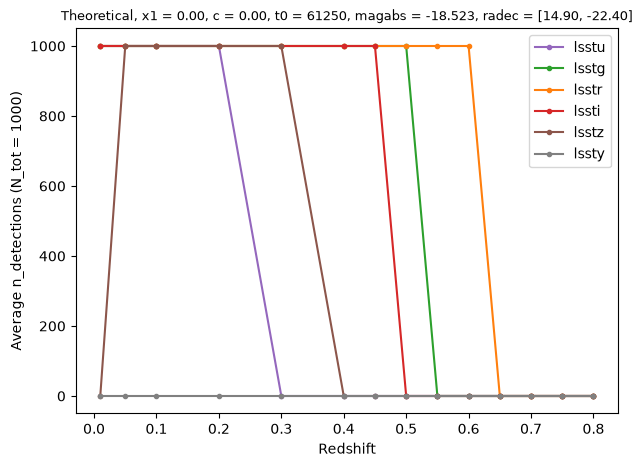

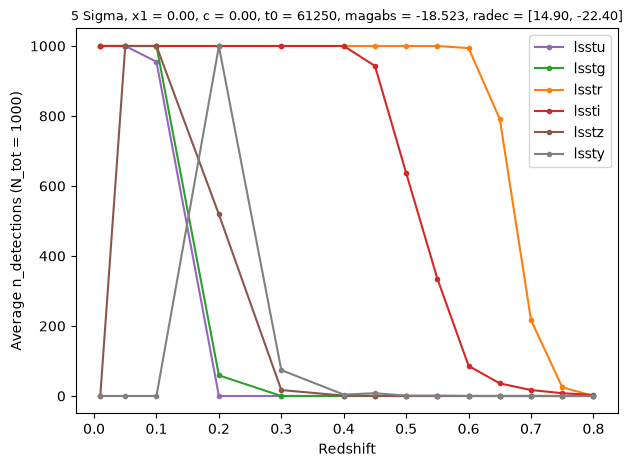

In [ ]:
# Plot detectability for each condition
# You can use ["theoretical", "5_sigma", "five_sigma_multi"] as I did not add it back before running

for condition in ["theoretical", "5_sigma"]:

    fig, ax = plt.subplots(figsize=(7, 5))
    # subset: chose one criterion
    subset = final_summary[final_summary["condition"] == condition]
    x1 = subset["x1"].iloc[0]
    c = subset["c"].iloc[0]
    t0 = subset["t0"].iloc[0]
    magabs = subset["magabs"].iloc[0]
    ra = subset["ra"].iloc[0]
    dec = subset["dec"].iloc[0]

    for band in lsst_bands:
        ax.plot(subset["z"],subset[band],marker=".",label=band,color=limit_mag_dict[band]["color"])
        
    ax.set_xlabel("Redshift")
    ax.set_ylabel("Average n_detections (N_tot = {})".format(N_tot))
    ax.set_title(
        f"{condition.replace('_', ' ').title()}, "
        f"x1 = {x1:.2f}, c = {c:.2f}, "
        f"t0 = {t0:.0f}, magabs = {magabs:.3f}, "
        f"radec = [{ra:.2f}, {dec:.2f}]",
        fontsize=9,
    )
    ax.legend()


## Now we simulate a larger random population of 10000

You can save the parameters of each source generated into a pandas DataFrame and then a parquet so you can restore the dataset. This is because if you re-open the noebook, you will get a differnet randomised population. Of course, if you prefer using a random seed, you can add seeds yourself into the functions.

In [ ]:
from lightcurve import lsst_bands
from lsst_functions import get_number_detections_allbands, five_sigma_detection_multiband

N_tot = 10000

snia_dict = generate_snia_dict(redshift = None, ra = None, dec = None, x1 = None, t0 = None, magabs = None, c = None)
print(snia_dict)
snia_param_list = generate_ordered_parameter_list(input_dict = True, params = snia_dict)
print(snia_param_list)
snia_models, data_models = generate_snia_lightcurve(*snia_param_list, bands = bands, in_mag = False, N_tot = N_tot, zp=30, tstart= tmin - 100, tstop = tmax, plot_curve = False, return_values = True, return_models = True, verbose = False)
dset = skysurvey.DataSet.from_targets_and_survey(snia_models, lsst, progress_bar=True, discard_bands=True)
dset_target_indices = dset.data.index.get_level_values(0).unique().values
print('dset target idx', dset_target_indices)
# Test every target
detected = []

for index in snia_models.data.index:
    total_detection_points = 0
    is_detected = False

    if index in dset_target_indices:
        is_detected = five_sigma_detection_multiband(dataset=dset,targets=snia_models,index=index,selection_criteria=selection_criteria)
    else:
        is_detected = False
        total_detection_points = 0

    if is_detected:
        total_detection_points = get_number_detections_allbands(dataset=dset,targets=snia_models,index=index,selection_criteria=selection_criteria)
        # targets isn't actually called in total_detection_points(), see lsst_functions.py for more info
    detected.append({
        "target": index,
        "z": snia_models.data.loc[index, "z"],
        "x1": snia_models.data.loc[index, "x1"],
        "c": snia_models.data.loc[index, "c"],
        "t0": snia_models.data.loc[index, "t0"],
        "ra": snia_models.data.loc[index, "ra"],
        "dec": snia_models.data.loc[index, "dec"],
        "magabs": snia_models.data.loc[index, "magabs"],
        "magobs": snia_models.data.loc[index, "magobs"],
        "template": 'salt2',

        "detected": is_detected,
        "n_detections": total_detection_points,

    })
detected = pd.DataFrame(detected)

# you will need to customise the directory where you save your parquet.

detected.to_parquet(
    "./SNParquets/my_test_parquet.parquet",
    engine="pyarrow",
    compression="zstd",
    index=False
)

{}
[None, None, None, None, None, None, None]
All params input as None. Using default sampling functions, but with p_cosmology.
CUSTOM MODEL IS {'redshift': {'func': <function sample_redshift_from_Rz at 0x73f16e1cee50>, 'kwargs': {'N': 10000, 'R_z': <function R_SFR at 0x73f16df9d220>, 'z_max': 1.0, 'p_cosmology': {'c': 299792.458, 'h0': 67.4, 'omega_M': 0.315, 'omega_K': 0, 'omega_L': 0.685, 'z_min': 0.0001, 'N_int_steps': 100, 'R0': {'SN Ia': <Quantity 23000. 1 / (yr Gpc3)>, 'SN CC': <Quantity 101000. 1 / (yr Gpc3)>, 'SN Ibc': <Quantity 101000. 1 / (yr Gpc3)>, 'SN II': <Quantity 101000. 1 / (yr Gpc3)>, 'TDE': <Quantity 8.e-07 1 / (yr Mpc3)>, 'KN': <Quantity 59.3 1 / (yr Gpc3)>}}}, 'as': 'z'}, 'radec': {'as': ['ra', 'dec'], 'func': <function random_radec at 0x73f171734bf0>, 'kwargs': {'dec_range': [-90, 90]}}}


100%|██████████| 6865/6865 [02:05<00:00, 54.54it/s]


dset target idx [   0    1    4 ... 9996 9997 9998]


In [76]:
detected = pd.read_parquet("SNParquets/my_test_parquet.parquet")

In [77]:
detected

,target,z,x1,c,t0,ra,dec,magabs,magobs,template,detected,n_detections
0,0,0.761887,0.405,-0.087,61455.253906,40.446648,-70.303032,-19.693794,23.740568,salt2,False,0
1,1,0.942811,0.685,0.210,61303.855469,98.857895,-1.704996,-18.620842,25.381453,salt2,False,0
2,2,0.609791,-2.100,-0.013,61550.843750,80.975731,51.814960,-19.005516,23.840076,salt2,False,0
3,3,0.766207,0.695,-0.021,61435.402344,325.743500,68.744888,-19.403614,24.045771,salt2,False,0
4,4,0.846390,0.205,0.019,61322.921875,84.326614,4.057542,-19.218693,24.495609,salt2,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,0.796044,0.075,0.096,61203.132812,185.055283,36.999428,-19.043140,24.507828,salt2,False,0
9996,9996,0.945961,-2.280,-0.081,61180.625000,149.334961,-13.556528,-19.111206,24.900002,salt2,False,0
9997,9997,0.853999,0.230,0.209,61129.468750,174.507416,7.540769,-18.733538,25.004627,salt2,False,0
9998,9998,0.869298,-2.115,0.011,61345.562500,61.717331,-17.265202,-18.928928,24.856594,salt2,False,0


In [78]:
# bin the data
z_bins = np.arange(0, 1.01, 0.02)
detected["z_bin"] = pd.cut(detected["z"],bins=z_bins,right=False)
n_sources = (detected[detected["detected"]].groupby("z_bin", observed=True).size())
n_points = (detected[detected["detected"]].groupby("z_bin", observed=True)["n_detections"].sum())

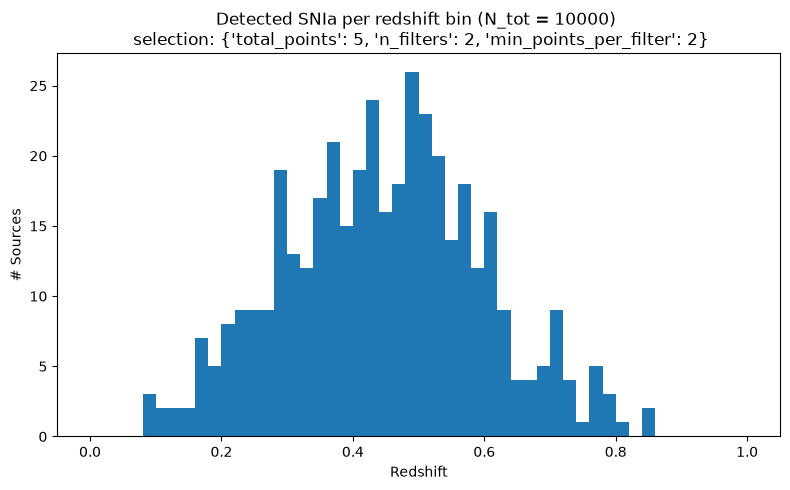

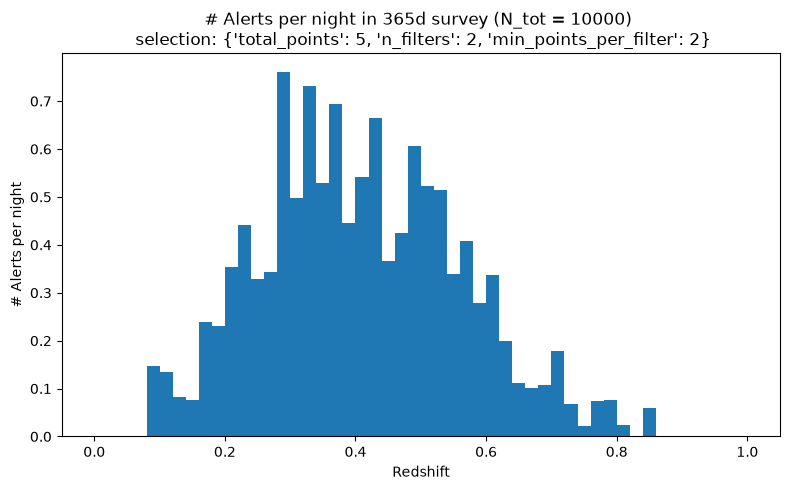

In [79]:
detected_sources = detected[detected["detected"]]

plt.figure(figsize=(8, 5))

plt.hist(detected_sources["z"],bins=z_bins)

plt.xlabel("Redshift")
plt.ylabel("# Sources")
plt.title(f"Detected SNIa per redshift bin (N_tot = {N_tot}) \n selection: {selection_criteria}")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(detected_sources['z'], weights = detected_sources["n_detections"]/365, bins=z_bins)

plt.xlabel("Redshift")
plt.ylabel("# Alerts per night")
plt.title(f"# Alerts per night in 365d survey (N_tot = {N_tot}) \n selection: {selection_criteria}")

plt.tight_layout()
plt.show()

In [80]:
detected_indices = detected.loc[detected["detected"], "target"]
detected_models = detected.loc[detected_indices]
detected_models

,target,z,x1,c,t0,ra,dec,magabs,magobs,template,detected,n_detections,z_bin
79,79,0.386171,0.570,0.177,61337.656250,320.634338,-62.622440,-18.831600,22.829971,salt2,True,5,"[0.38, 0.4)"
89,89,0.340335,-1.045,-0.071,61496.261719,188.179550,-3.233650,-19.420544,21.920406,salt2,True,20,"[0.34, 0.36)"
107,107,0.091517,1.030,0.034,61274.875000,33.321720,-44.414928,-19.428423,18.754032,salt2,True,22,"[0.08, 0.1)"
109,109,0.498621,0.440,-0.080,61270.218750,269.660583,-56.639397,-19.445971,22.873489,salt2,True,10,"[0.48, 0.5)"
150,150,0.527908,-0.455,0.014,61461.308594,127.340828,-27.702463,-19.086178,23.381817,salt2,True,6,"[0.52, 0.54)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9934,9934,0.567134,1.035,-0.020,61354.433594,44.256252,-0.436598,-19.631929,23.023355,salt2,True,12,"[0.56, 0.58)"
9944,9944,0.622530,0.235,-0.083,61504.308594,240.804718,-32.824593,-19.416805,23.483187,salt2,True,12,"[0.62, 0.64)"
9953,9953,0.276030,-3.065,-0.092,61301.000000,43.165993,-21.131516,-19.124689,21.691856,salt2,True,15,"[0.26, 0.28)"
9975,9975,0.613750,0.910,-0.087,61322.078125,355.005402,-74.930725,-19.834864,23.027752,salt2,True,7,"[0.6, 0.62)"


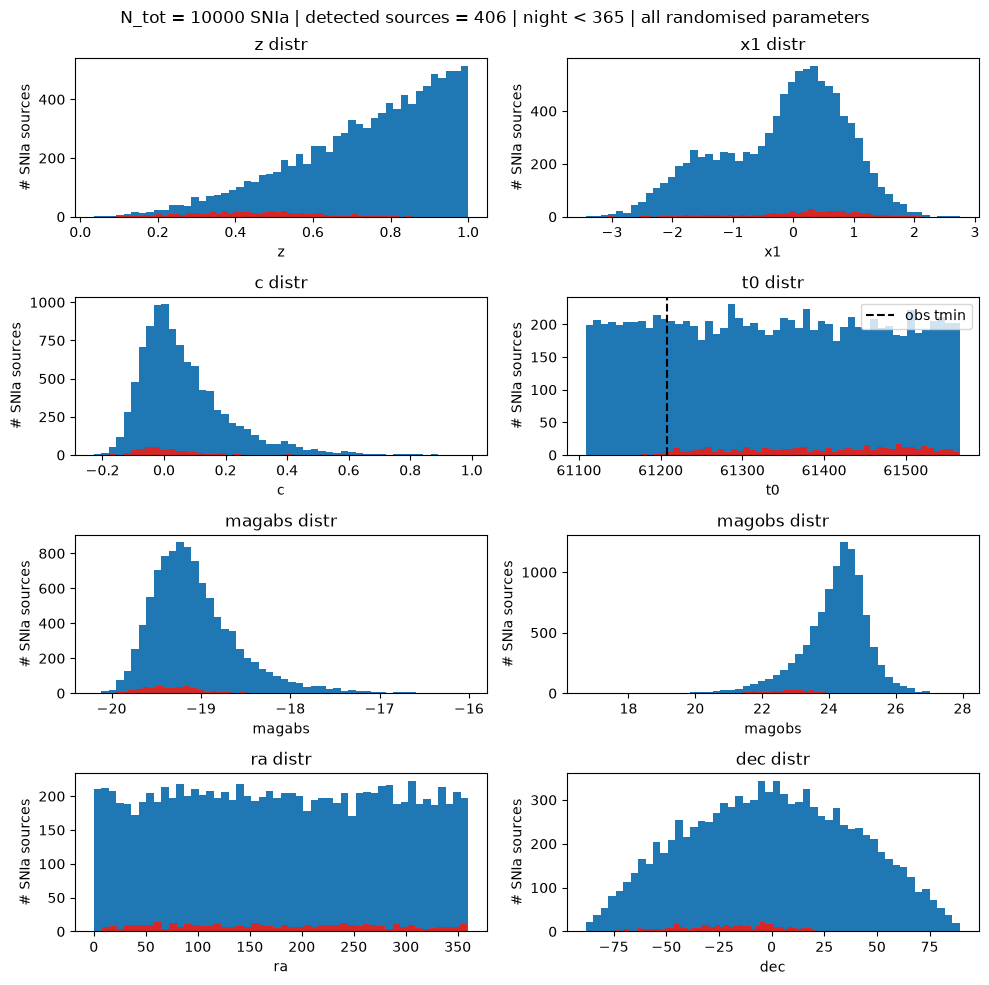

In [81]:
params = ['z', 'x1', 'c', 't0', 'magabs', 'magobs', 'ra', 'dec']

fig, axs = plt.subplots(4, 2, figsize=(10, 10))

for ax, param in zip(axs.flat, params):
    ax.hist(snia_models.data[param], bins=50, color = 'tab:blue') #axes.hist --> use counts, bins = ...
    ax.hist(detected_models[param], bins=50, color = 'tab:red')
    if param == 't0':
        ax.axvline(tmin, color = 'k', linestyle = '--', label = 'obs tmin')
        ax.legend()
    ax.set_xlabel(param)
    ax.set_ylabel("# SNIa sources")
    ax.set_title(f"{param} distr")

# Hide unused subplot
for ax in axs.flat[len(params):]:
    ax.set_visible(False)
plt.suptitle(f'N_tot = {N_tot} SNIa | detected sources = {len(detected_models)} | night < 365 | all randomised parameters')
plt.tight_layout()

plt.show()


### Further tests

In [82]:
from lsst_functions import n_detections_sources
N_tot = 1000
redshift_list = [0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75]

snia_dict = generate_snia_dict(redshift=None,ra=None,dec=None,x1=None,t0=None,magabs=-19.323,c=None)
snia_param_list = generate_ordered_parameter_list(input_dict=True,params=snia_dict)

detection_summary = n_detections_sources(snia_param_list = snia_param_list, opsim = lsst, N_tot = N_tot, redshift_list = redshift_list)

Start: 2026-06-17 04:52:30.000
End:   2027-06-10 01:46:52.500
Duration: 1.0 years
[0.15, None, None, None, -19.323, None, None]
CUSTOM MODEL IS {'radec': {'as': ['ra', 'dec'], 'func': <function random_radec at 0x73f171734bf0>, 'kwargs': {'dec_range': [-90, 90]}}, 'redshift': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': 0.15}, 'as': 'z'}, 'magabs': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': -19.323}, 'as': 'magabs'}}


100%|██████████| 665/665 [00:13<00:00, 49.74it/s]


[0.2, None, None, None, -19.323, None, None]
CUSTOM MODEL IS {'radec': {'as': ['ra', 'dec'], 'func': <function random_radec at 0x73f171734bf0>, 'kwargs': {'dec_range': [-90, 90]}}, 'redshift': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': 0.2}, 'as': 'z'}, 'magabs': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': -19.323}, 'as': 'magabs'}}


100%|██████████| 678/678 [00:14<00:00, 46.89it/s]


[0.25, None, None, None, -19.323, None, None]
CUSTOM MODEL IS {'radec': {'as': ['ra', 'dec'], 'func': <function random_radec at 0x73f171734bf0>, 'kwargs': {'dec_range': [-90, 90]}}, 'redshift': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': 0.25}, 'as': 'z'}, 'magabs': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': -19.323}, 'as': 'magabs'}}


...

100%|██████████| 694/694 [00:15<00:00, 43.66it/s]


[0.7, None, None, None, -19.323, None, None]
CUSTOM MODEL IS {'radec': {'as': ['ra', 'dec'], 'func': <function random_radec at 0x73f171734bf0>, 'kwargs': {'dec_range': [-90, 90]}}, 'redshift': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': 0.7}, 'as': 'z'}, 'magabs': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': -19.323}, 'as': 'magabs'}}


100%|██████████| 672/672 [00:12<00:00, 55.04it/s]


[0.75, None, None, None, -19.323, None, None]
CUSTOM MODEL IS {'radec': {'as': ['ra', 'dec'], 'func': <function random_radec at 0x73f171734bf0>, 'kwargs': {'dec_range': [-90, 90]}}, 'redshift': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': 0.75}, 'as': 'z'}, 'magabs': {'func': <function fixed_param at 0x73f16e1ceae0>, 'kwargs': {'size': 1000, 'value': -19.323}, 'as': 'magabs'}}


100%|██████████| 679/679 [00:13<00:00, 49.00it/s]


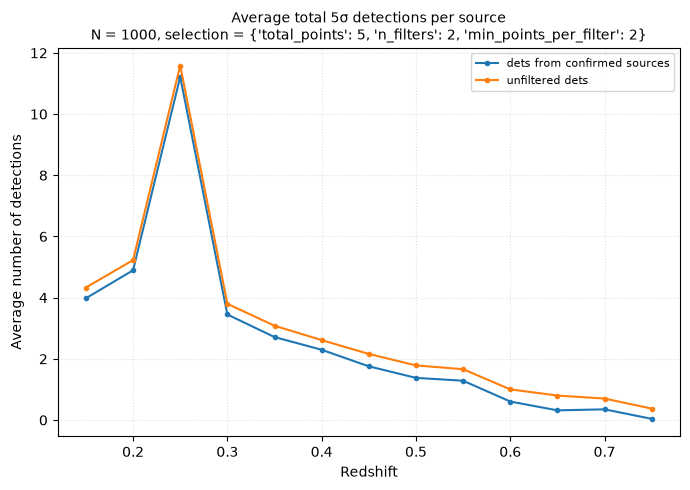

In [ ]:
# total number of detections divided by number of sources N_tot.
# and then plotting how many of these belong to confirmed SNIa sources.
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(detection_summary["z"], detection_summary["n_det"]/N_tot, marker=".", label = 'dets from confirmed sources')
ax.plot(detection_summary["z"], detection_summary["n_det_unfiltered"]/N_tot, marker=".", label = 'unfiltered dets')

ax.set_xlabel("Redshift")
ax.set_ylabel("Average number of detections")
ax.set_title(
    f"Average total 5σ detections per source\n"
    f"N = {N_tot}, selection = {selection_criteria}",
    fontsize = 10
)
ax.legend(fontsize = 8)
ax.grid(alpha = 0.25, color = 'grey', linestyle = ':')

plt.tight_layout()
plt.show()

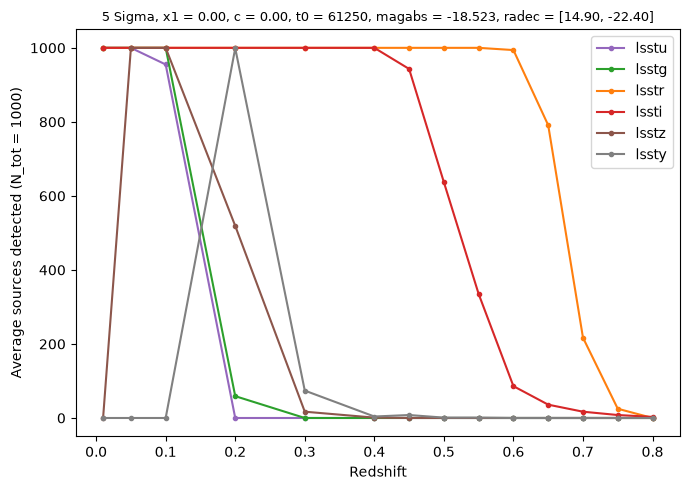

In [86]:
for condition in ["5_sigma"]:

    fig, ax = plt.subplots(figsize=(7, 5))

    subset = final_summary[
        final_summary["condition"] == condition
    ]
    x1 = subset["x1"].iloc[0]
    c = subset["c"].iloc[0]
    t0 = subset["t0"].iloc[0]
    magabs = subset["magabs"].iloc[0]
    ra = subset["ra"].iloc[0]
    dec = subset["dec"].iloc[0]

    for band in lsst_bands:
        ax.plot(
            subset["z"],
            subset[band],
            marker=".",
            label=band,
            color=limit_mag_dict[band]["color"],
        )
        

    ax.set_xlabel("Redshift")
    ax.set_ylabel("Average sources detected (N_tot = {})".format(N_tot))
    ax.set_title(
        f"{condition.replace('_', ' ').title()}, "
        f"x1 = {x1:.2f}, c = {c:.2f}, "
        f"t0 = {t0:.0f}, magabs = {magabs:.3f}, "
        f"radec = [{ra:.2f}, {dec:.2f}]",
        fontsize=9,
    )
    ax.legend()

    plt.tight_layout()
    plt.show()

In [114]:
snia_models.data.iloc[0]

z               0.761887
x1                 0.405
c                 -0.087
t0          61455.253906
ra             40.446648
dec           -70.303032
magabs        -19.693794
magobs         23.740568
template           salt2
Name: 0, dtype: object

In [116]:
data_models[0]['params']

{'z': np.float32(0.7618872),
 'x1': np.float32(0.405),
 'c': np.float32(-0.087),
 't0': np.float32(61455.254),
 'magabs': np.float32(-19.693794),
 'ra': np.float32(40.446648),
 'dec': np.float32(-70.30303)}